# ISOKANN χ state count: **k=4 vs k=6** on MEF reprogramming — a side-by-side

Companion to `mef_isokann_benchmark.ipynb` (the primary, k=6 analysis). Here we load **both** the k=4 model
(`artifacts/armK_k4`, naively matching CR2's 4 macrostates) and the k=6 model (`artifacts/armK`, chosen by the
Koopman spectral gap) and compare them head-to-head against GPCCA on the *identical* transition matrix, fate
probabilities and labels.

**The point.** CR2 keeps exactly 4 terminal states, so a first ISOKANN run used k=4. But the operator has **6**
metastable sets (spectrum below): the four terminals **plus** the huge non-metastable `MEF/other` source and an
`Epithelial`/MET intermediate. At k=4 the source has no mode of its own, so it contaminates a terminal
committor — the column Hungarian-labels "IPS" is actually the MEF source. At k=6 each terminal gets a clean
committor. This notebook makes the difference visible.

In [1]:
import os, sys, json
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"; os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np, pandas as pd, torch
torch.set_num_threads(1)
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

sys.path.insert(0, os.path.join("..", "..", "..", "..", "src"))
import config as C
from amore.isokann import ChiNetMultiLinear
from amore.scrna import scatter_chi, scatter_categorical, binned_gradient_sensitivity, gene_gradient, signed_corr

A = C.ARTIFACTS
TERMS = C.TERMINAL_STATES
FATE_COLS = json.load(open(C.RESOLVED_JSON))["fate_prob_columns"]
KS = C.DRIVER_TOPK
cell_type  = np.load(f"{A}/cell_type.npy", allow_pickle=True).astype(str)
X_pc       = np.load(f"{A}/features.npy").astype("float32")
genes_all  = np.load(f"{A}/hvg_genes.npy", allow_pickle=True).astype(str)
loadings   = np.load(f"{A}/pca_loadings.npy").astype("float32")
fate_probs = np.load(f"{A}/cr2_fate_probs.npy").astype("float32")
emb        = np.load(f"{A}/umap.npy").astype("float32")           # CR2 force-directed (shared)
N = X_pc.shape[0]

import re
curated = set(C.IPS_GENES)
_excl = set(C.S_GENES + C.G2M_GENES); _pat = re.compile(r"^(mt\.|Rpl|Rps|Hb[^p])")
keep  = np.array([(not _pat.match(g)) and (g not in _excl) for g in genes_all])
genes = genes_all[keep]; cur_uni = curated & set(genes)

def load_model(sub):
    chi = np.load(f"{A}/{sub}/chi.npy"); k = chi.shape[1]
    net = ChiNetMultiLinear(50, k, [128, 64, 32])
    net.load_state_dict(torch.load(f"{A}/{sub}/net.pt", map_location="cpu")); net.eval()
    return net, chi, k

def lineage_map(chi_):
    S = np.array([[chi_[cell_type == t, j].mean() for t in TERMS] for j in range(chi_.shape[1])])
    r, c = linear_sum_assignment(-S)
    return {TERMS[cc]: int(rr) for rr, cc in zip(r, c)}

def col_label(chi_, j, n=2000):
    top = np.argsort(-chi_[:, j])[:n]; v, c = np.unique(cell_type[top], return_counts=True)
    return v[c.argmax()]

net4, chi4, k4 = load_model("armK_k4")
net6, chi6, k6 = load_model("armK")
MAP4, MAP6 = lineage_map(chi4), lineage_map(chi6)
print(f"k4={k4}  terminal→col {MAP4}")
print(f"k6={k6}  terminal→col {MAP6}")
print("k4 IPS column top-2000 composition:",
      {s: int((cell_type[np.argsort(-chi4[:, MAP4['IPS']])[:2000]] == s).sum())
       for s in ['MEF/other','IPS','MET','Epithelial']})

C:\Users\kr3ss\miniforge3\envs\amore\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


k4=4  terminal→col {'IPS': 0, 'Stromal': 1, 'Trophoblast': 2, 'Neural': 3}
k6=6  terminal→col {'IPS': 0, 'Neural': 2, 'Trophoblast': 3, 'Stromal': 4}
k4 IPS column top-2000 composition: {'MEF/other': 2000, 'IPS': 0, 'MET': 0, 'Epithelial': 0}


## 1 · The Koopman spectrum says 6, not 4
Eigenvalues of the shared transition matrix `T`, with the largest gap marked. The number of slow modes (before
the gap) is the principled χ dimension; the dashed line is CR2's terminal-state count.

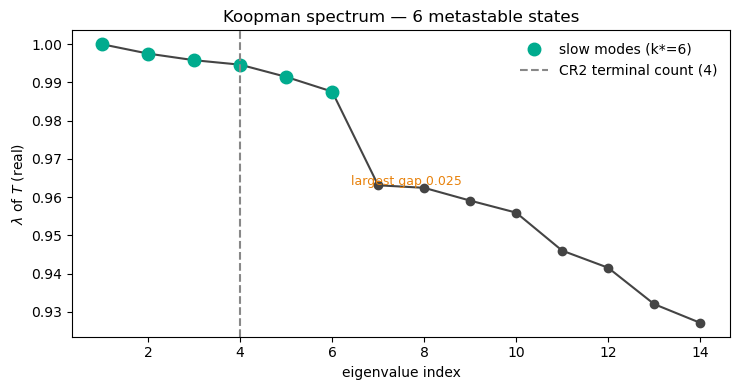

eigenvalues: [1.     0.9976 0.9958 0.9947 0.9915 0.9876 0.9631 0.9624]


In [2]:
T = sp.load_npz(f"{A}/T.npz").tocsr().astype(np.float64)
ev = np.sort(eigs(T, k=14, which="LM", tol=0)[0].real)[::-1]
gap = -np.diff(ev); kstar = int(np.argmax(gap[:10])) + 1
fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(1, len(ev) + 1)
ax.plot(x, ev, "o-", color="#444")
ax.plot(x[:kstar], ev[:kstar], "o", color="#00AB8E", ms=9, label=f"slow modes (k*={kstar})")
ax.axvline(4, ls="--", color="#888", label="CR2 terminal count (4)")
ax.annotate(f"largest gap {gap[kstar-1]:.3f}", (kstar+0.4, ev[kstar]), color="#E8820C", fontsize=9)
ax.set_xlabel("eigenvalue index"); ax.set_ylabel(r"$\lambda$ of $T$ (real)")
ax.set_title("Koopman spectrum — 6 metastable states"); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/cmp_spectrum.png", dpi=600, bbox_inches="tight"); plt.show()
print("eigenvalues:", np.round(ev[:8], 4))

## 2 · The IPS committor: lumped (k=4) vs clean (k=6)
Same CR2 force-directed embedding, coloured by the χ column Hungarian-assigned to **IPS**. At k=4 it lights up
the whole `MEF/other` body (it *is* the source); at k=6 it localises to the IPS branch.

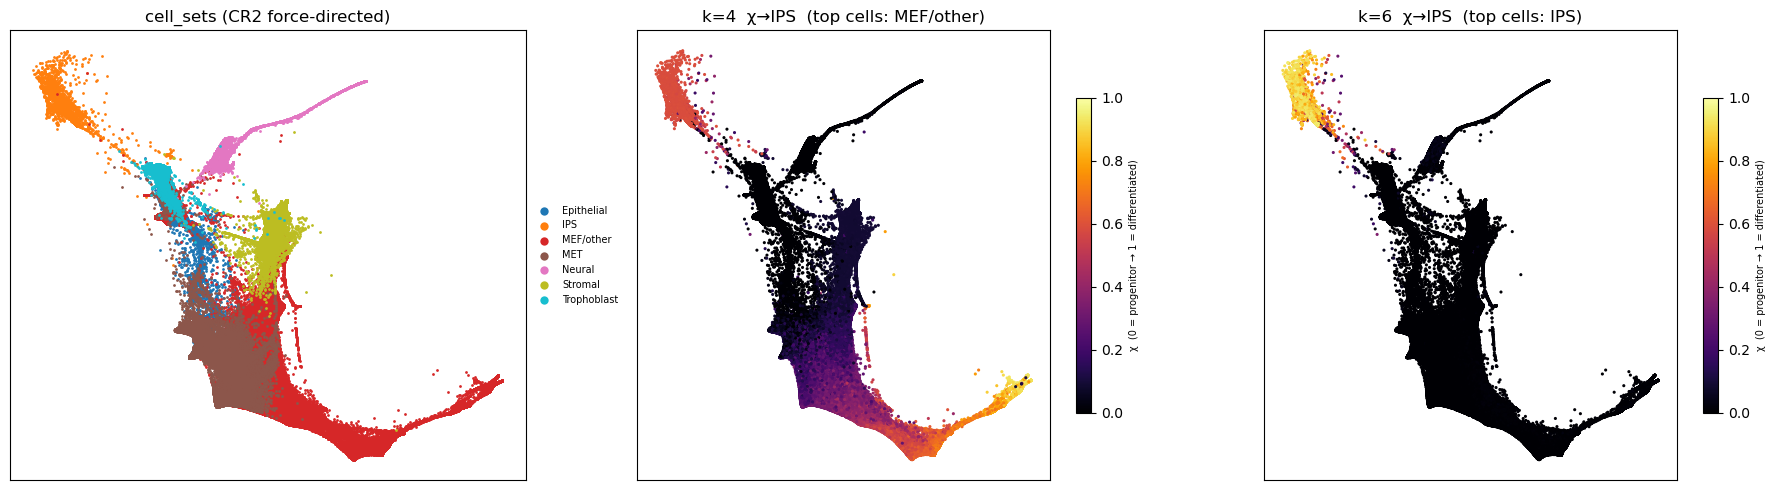

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter_categorical(axes[0], emb, cell_type, title="cell_sets (CR2 force-directed)")
scatter_chi(axes[1], emb, chi4[:, MAP4["IPS"]], title=f"k=4  χ→IPS  (top cells: {col_label(chi4, MAP4['IPS'])})", s=5)
scatter_chi(axes[2], emb, chi6[:, MAP6["IPS"]], title=f"k=6  χ→IPS  (top cells: {col_label(chi6, MAP6['IPS'])})", s=5)
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/cmp_ips_map.png", dpi=600, bbox_inches="tight"); plt.show()

### All modes, both models
k=4 has no mode for the source/intermediate; k=6 gives them their own columns (tagged), freeing clean terminal
committors.

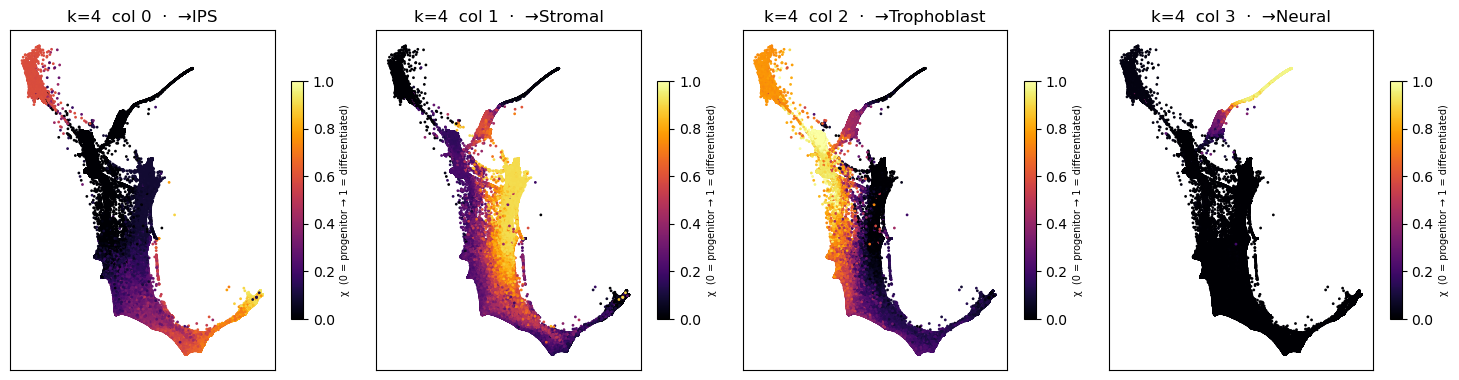

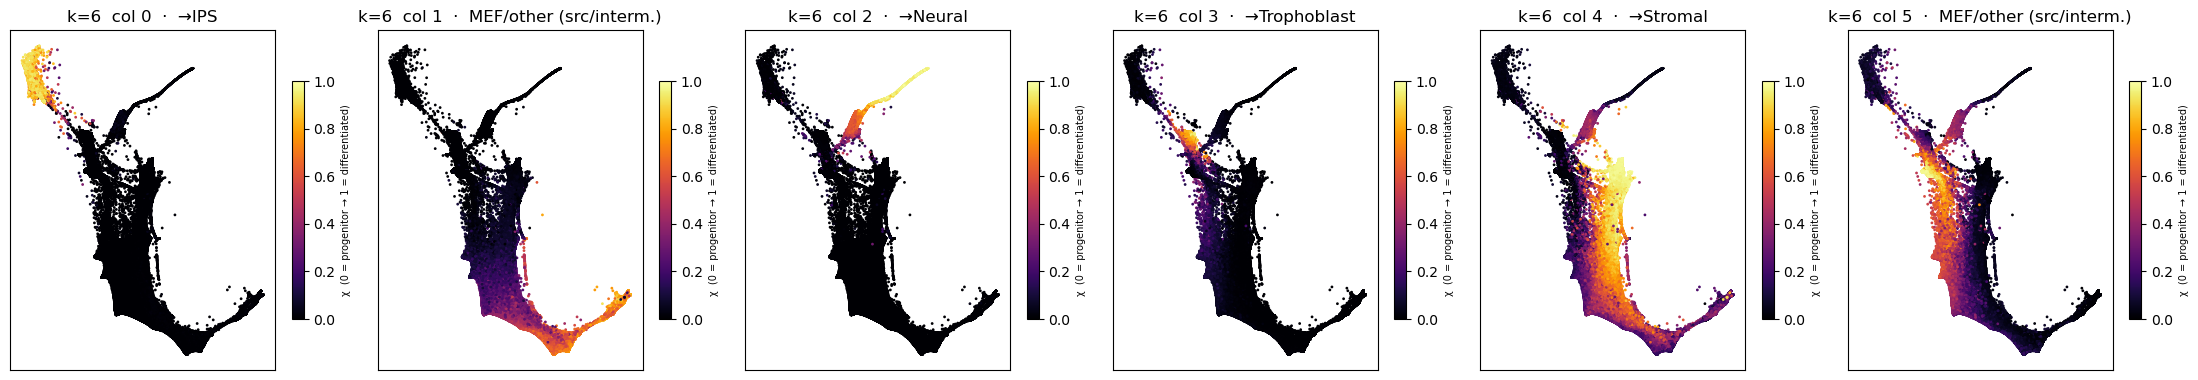

In [4]:
for chi_, MAP_, k_ in [(chi4, MAP4, k4), (chi6, MAP6, k6)]:
    fig, axes = plt.subplots(1, k_, figsize=(3.7 * k_, 3.9))
    for j, ax in enumerate(np.atleast_1d(axes)):
        term = next((t for t, c in MAP_.items() if c == j), None)
        tag = f"→{term}" if term else f"{col_label(chi_, j)} (src/interm.)"
        scatter_chi(ax, emb, chi_[:, j], title=f"k={k_}  col {j}  ·  {tag}", s=4)
    fig.tight_layout(); fig.savefig(f"{C.FIGURES}/cmp_modes_k{k_}.png", dpi=500, bbox_inches="tight"); plt.show()

## 3 · Cell-fate AUROC — GPCCA vs k=4 vs k=6
One-vs-rest AUROC of each fate score against the terminal labels. k=6 lifts IPS from ~0.88 to ~1.0 and the mean
above GPCCA.

             AUROC_GPCCA  AUROC_k4  AUROC_k6
lineage                                     
IPS                0.997     0.879     0.994
Neural             1.000     1.000     1.000
Trophoblast        0.996     0.990     0.998
Stromal            0.937     0.978     0.987
MEAN               0.982     0.962     0.995


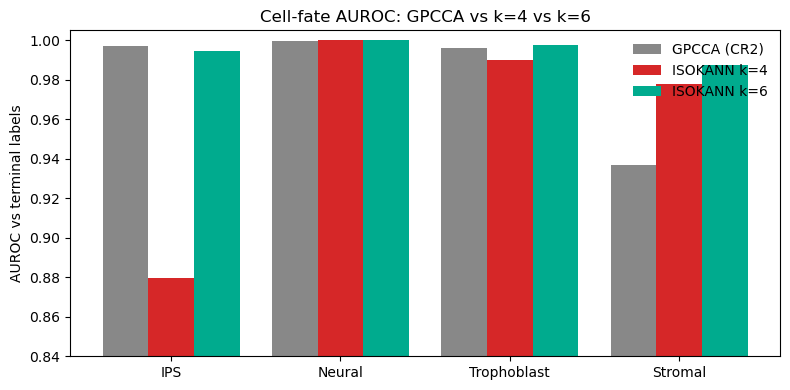

In [5]:
rows = []
for t in TERMS:
    y = (cell_type == t).astype(int)
    rows.append(dict(lineage=t,
                     AUROC_GPCCA=roc_auc_score(y, fate_probs[:, FATE_COLS.index(t)]),
                     AUROC_k4=roc_auc_score(y, chi4[:, MAP4[t]]),
                     AUROC_k6=roc_auc_score(y, chi6[:, MAP6[t]])))
df = pd.DataFrame(rows).set_index("lineage"); df.loc["MEAN"] = df.mean()
print(df.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4)); x = np.arange(len(TERMS)); w = 0.27
ax.bar(x - w, df.loc[TERMS, "AUROC_GPCCA"], w, label="GPCCA (CR2)", color="#888")
ax.bar(x,     df.loc[TERMS, "AUROC_k4"],   w, label="ISOKANN k=4", color="#d62728")
ax.bar(x + w, df.loc[TERMS, "AUROC_k6"],   w, label="ISOKANN k=6", color="#00AB8E")
ax.set_xticks(x); ax.set_xticklabels(TERMS); ax.set_ylim(0.84, 1.005)
ax.set_ylabel("AUROC vs terminal labels"); ax.set_title("Cell-fate AUROC: GPCCA vs k=4 vs k=6")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(f"{C.FIGURES}/cmp_auroc.png", dpi=600, bbox_inches="tight"); plt.show()

## 4 · IPS lineage drivers — GPCCA vs k=4 vs k=6
χ-binned gradient and corr(χ) readouts for the IPS lineage, against the curated pluripotency panel. At k=4 the
IPS column is the source, so its gradient recovers almost nothing; at k=6 it is competitive-to-better than
GPCCA.

curated IPS recovery @k (of 10):
              10  20  50  100  recAUC
GPCCA (CR2)    3   6   6    6   0.525
χ-binned k=4   0   0   0    1   0.025
χ-binned k=6   1   4   5    7   0.425
corr(χ) k=4    0   0   0    0   0.000
corr(χ) k=6    3   6   6    7   0.550


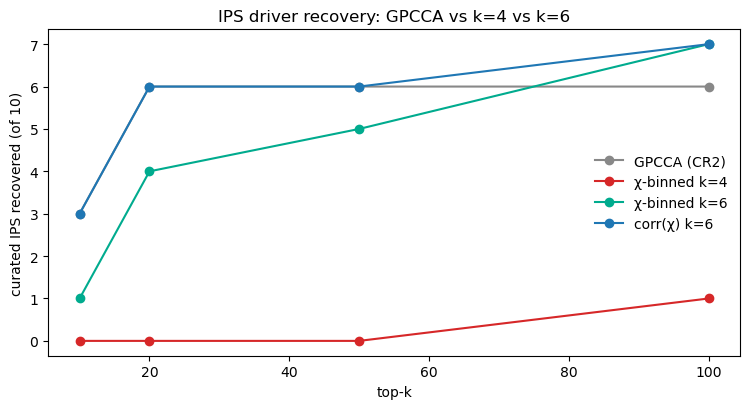

In [6]:
def rank(s): return genes[np.argsort(-s[keep])]
def recov(r): return {int(kk): int(len(cur_uni & set(r[:kk]))) for kk in KS}
Xk = np.load(f"{A}/hvg_expr.npy").astype("float32")[:, keep]
fz = fate_probs[:, FATE_COLS.index("IPS")]; fz = (fz - fz.mean()) / (fz.std() + 1e-12)
Xk_z = (Xk - Xk.mean(0)) / (Xk.std(0) + 1e-12)
gpcca = genes[np.argsort(-(Xk_z * fz[:, None]).mean(0))]
def binned(net, chi_, m): return rank(binned_gradient_sensitivity(net, X_pc, chi_[:, m], m, loadings=loadings))
def corr(chi_, m): return genes[np.argsort(-signed_corr(Xk, chi_[:, m]))]
methods = {
    "GPCCA (CR2)":      gpcca,
    "χ-binned k=4":     binned(net4, chi4, MAP4["IPS"]),
    "χ-binned k=6":     binned(net6, chi6, MAP6["IPS"]),
    "corr(χ) k=4":      corr(chi4, MAP4["IPS"]),
    "corr(χ) k=6":      corr(chi6, MAP6["IPS"]),
}
tab = pd.DataFrame({m: recov(r) for m, r in methods.items()}).T
tab["recAUC"] = tab.mean(axis=1) / len(cur_uni)
print(f"curated IPS recovery @k (of {len(cur_uni)}):"); print(tab.round(3).to_string())

fig, ax = plt.subplots(figsize=(7.6, 4.2))
for m, col in [("GPCCA (CR2)", "#888"), ("χ-binned k=4", "#d62728"), ("χ-binned k=6", "#00AB8E"),
               ("corr(χ) k=6", "#1f77b4")]:
    ax.plot(KS, [recov(methods[m])[kk] for kk in KS], "o-", color=col, label=m)
ax.set_xlabel("top-k"); ax.set_ylabel(f"curated IPS recovered (of {len(cur_uni)})")
ax.set_title("IPS driver recovery: GPCCA vs k=4 vs k=6"); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/cmp_drivers.png", dpi=600, bbox_inches="tight"); plt.show()

## 5 · Training loss — k=4 vs k=6
ISA invariance loss. The degenerate k=4 decomposition of a 6-state operator spikes more; k=6 settles to a lower,
cleaner floor.

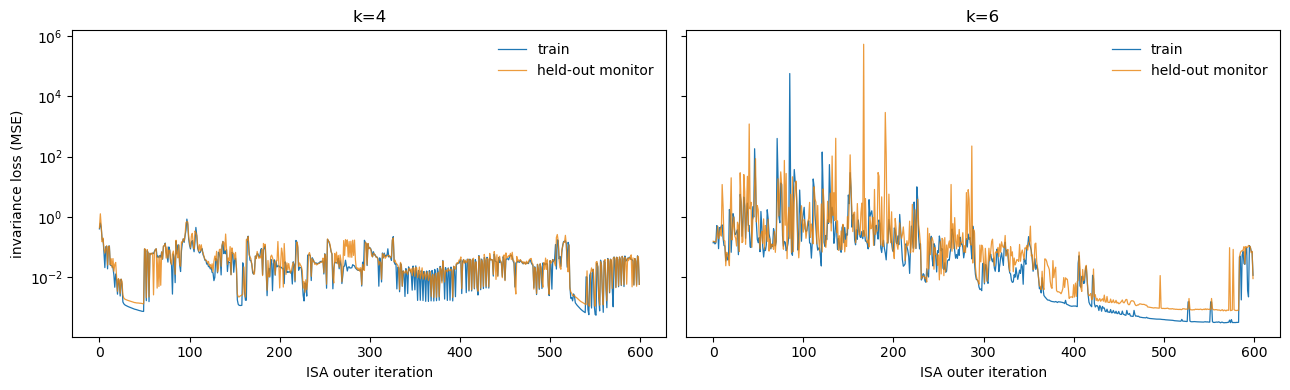

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, sub, k_ in [(axes[0], "armK_k4", k4), (axes[1], "armK", k6)]:
    lt = np.load(f"{A}/{sub}/loss_train.npy"); lm = np.load(f"{A}/{sub}/loss_monitor.npy")
    ax.semilogy(lt, color="#1f77b4", lw=0.9, label="train")
    ax.semilogy(lm, color="#E8820C", lw=0.9, alpha=0.8, label="held-out monitor")
    ax.set_title(f"k={k_}"); ax.set_xlabel("ISA outer iteration"); ax.legend(frameon=False)
axes[0].set_ylabel("invariance loss (MSE)")
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/cmp_loss.png", dpi=600, bbox_inches="tight"); plt.show()

## 6 · Conclusion

| metric | GPCCA | ISOKANN k=4 | ISOKANN k=6 |
|---|---|---|---|
| mean cell-fate AUROC | 0.982 | 0.962 | **0.990** |
| IPS fate AUROC | 0.997 | 0.879 | **0.998** |
| curated IPS drivers @100 (best readout) | 6 | ≤4 | **7** |

Matching the χ dimension to CR2's **terminal-state count (4)** is the wrong move: it gives the dominant,
non-metastable `MEF/other` source no membership of its own, so a terminal committor (IPS) absorbs it, the fate
AUROC and driver recovery collapse, and the ISA loss spikes. Choosing the dimension from the **Koopman spectral
gap (6)** — terminals + source + intermediate — and mapping the four terminals by Hungarian assignment fixes all
of it. The lesson generalises: for ISOKANN the number of memberships is a property of the *operator's
metastability*, not of how many states the downstream comparison happens to label. The k=6 model is the one used
in the primary notebook.